In [2]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2


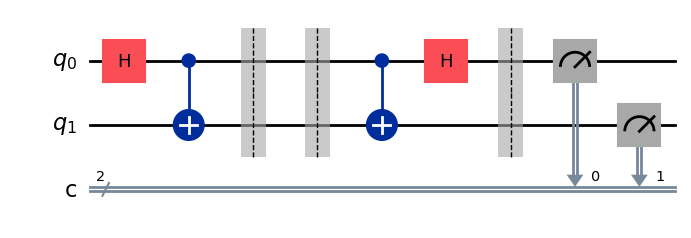

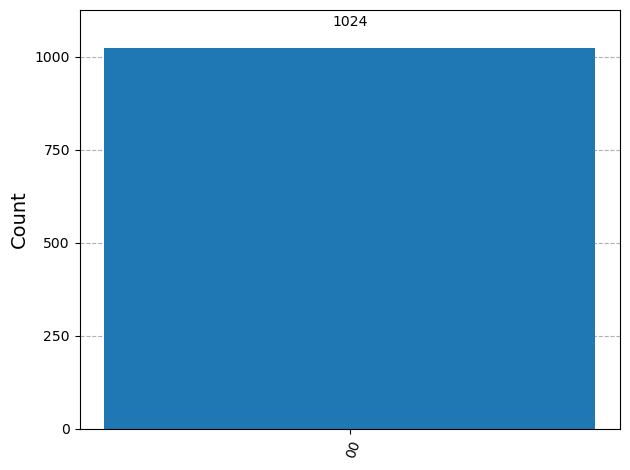

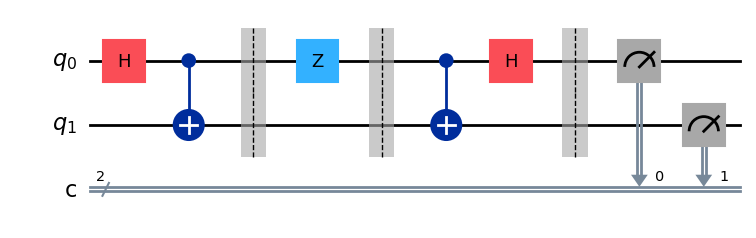

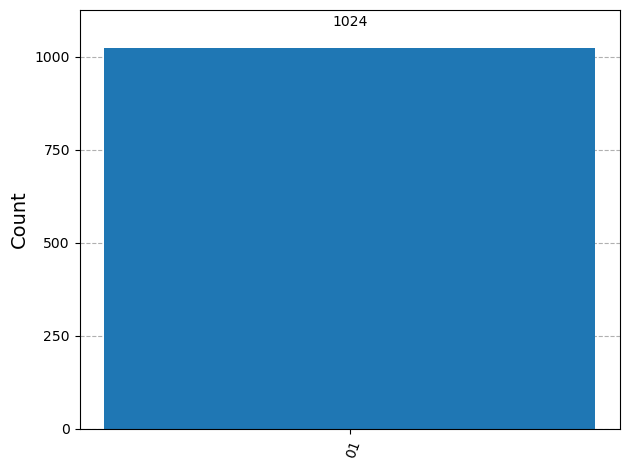

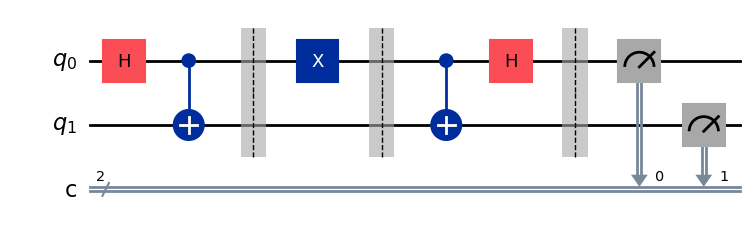

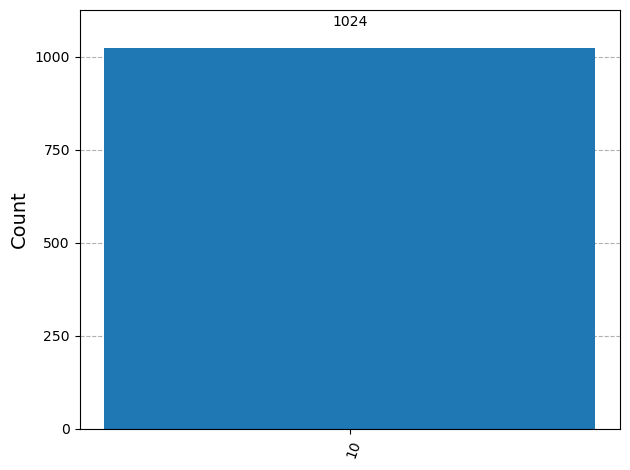

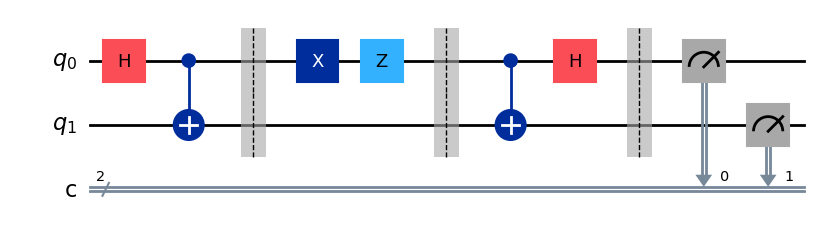

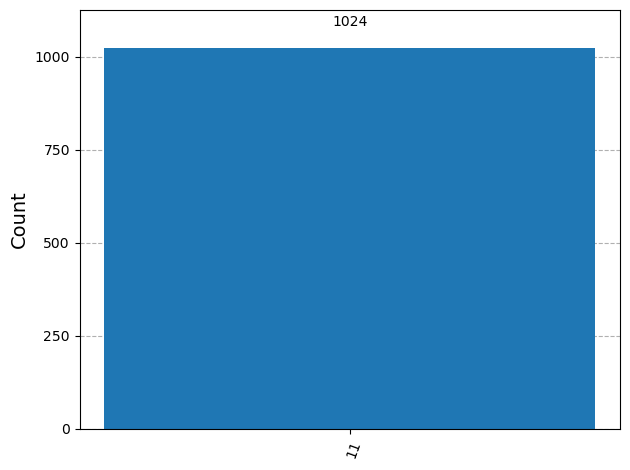

In [15]:
for bits in ['00', '01', '10', '11']:

    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)
    qc.h(qr[0])
    qc.cx(qr[0], qr[1])
    qc.barrier()
    if bits[0] == '1':
        qc.x(qr[0])
    if bits[1] == '1':
        qc.z(qr[0])
    qc.barrier()
    qc.cx(qr[0], qr[1])
    qc.h(qr[0])
    qc.barrier()
    qc.measure(qr, cr)

    display(qc.draw('mpl'))

    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    display(plot_histogram(result.get_counts(qc)))
